# KIT Automotive OBD-II Cleaning and Data Quality Assessment Report

**Mode:** read-only artifact audit  
**Reference run:** `2026-07-19-data-layer-v1`

## Introduction

This notebook validates the existing cleaning artifacts for the explicit reference run above. It checks schema and four-key identity, UTC timestamps, within-segment 1 Hz continuity, missingness, pipeline quality flags, physical ranges, and high-level signal behaviour.

For the reference run, the checks below cover 249,694 cleaned rows from 81 trips and 118 segments. The saved cleaning report records 56 rows with imputation, 3,470 rows with a suspicious value, and no rows with a hard-invalid source. Within the scope of these checks, the artifacts are suitable for downstream feature engineering and analysis.

Synthetic proxy validation and Model Layer suitability are outside this notebook's scope.

## Context & Methods

The report combines two complementary views:

- **Pipeline audit evidence:** the existing `cleaning_report.json` and `cleaning_quality.csv` artifacts produced by the cleaning pipeline.
- **Read-only artifact checks:** independent calculations over `cleaned_dataset.csv` and `cleaning_quality.csv` without rerunning or modifying the pipeline.

### Key assumptions

- `RUN_ID` identifies a completed Data Layer run under `data/processed/runs/`.
- One raw KIT CSV corresponds to one `trip_id`.
- Raw `Time` values are local time-of-day values interpreted using the configured `Europe/Berlin` timezone; emitted timestamps are normalized to UTC.
- The canonical sample identity is `(timestamp, trip_id, segment_id, row_in_segment)`.

### Reproducibility and safety

Running this notebook reads existing artifacts only. It does not call `run_cleaning`, `run_quality_audit`, or any other stage that writes pipeline outputs. Change `RUN_ID` in the setup cell to audit a different completed run.


## 1. Schema Validation and Core Structural Integrity

This section verifies the structural correctness of the selected run's cleaned and quality artifacts against the current cleaning schema.

The assessment covers:

- trip and segment counts;
- required and unexpected columns;
- ordered output-column contracts;
- equality of cleaned and quality row counts;
- uniqueness of the canonical four-column sample key.

The composite key `[timestamp, trip_id, segment_id, row_in_segment]` is the identity contract for canonical observations.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Find the repository without scanning unrelated descendant trees."""
    resolved = start.resolve()
    for candidate in (resolved, *resolved.parents):
        if (candidate / "data_layer" / "pipeline_data" / "paths.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Run the notebook from the granite-lifeline repository or one of its subdirectories."
    )


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_layer.data_cleaning.src.cleaning_core import (
    build_output_columns,
    build_quality_output_columns,
    load_config,
)
from data_layer.pipeline_data.paths import RunLayout

RUN_ID = "2026-07-19-data-layer-v1"
CONFIG_PATH = REPO_ROOT / "data_layer/data_cleaning/src/cleaning_config.yaml"
layout = RunLayout.for_run_id(RUN_ID, repo_root=REPO_ROOT)

required_artifacts = {
    "cleaned dataset": layout.cleaned_dataset,
    "cleaning quality": layout.cleaning_quality,
    "cleaning report": layout.cleaning_report,
}
missing_artifacts = [
    f"{label}: {path}"
    for label, path in required_artifacts.items()
    if not path.is_file()
]
assert not missing_artifacts, "Missing reference-run artifacts:\n" + "\n".join(missing_artifacts)

config = load_config(CONFIG_PATH)
cleaned = pd.read_csv(layout.cleaned_dataset, low_memory=False)
quality = pd.read_csv(layout.cleaning_quality, low_memory=False)
audit_report = json.loads(layout.cleaning_report.read_text(encoding="utf-8"))

print("=== Read-Only Artifact Summary ===")
print("Run ID:          ", RUN_ID)
print("Pipeline version:", audit_report["pipeline_version"])
print(f"Source files:     {audit_report['source_files']}")
print(f"Cleaned rows:     {len(cleaned):,}")
print(f"Trips:            {cleaned['trip_id'].nunique()}")
print(f"Segments:         {cleaned[['trip_id', 'segment_id']].drop_duplicates().shape[0]}")
display(cleaned.head())


=== Read-Only Artifact Summary ===
Run ID:           2026-07-19-data-layer-v1
Pipeline version: 3.0
Source files:     81
Cleaned rows:     249,694
Trips:            81
Segments:         118


,timestamp,trip_id,segment_id,row_in_segment,coolant_temp,map,rpm,speed,intake_temp,maf,tps,ambient_temp,accel_pedal_d,accel_pedal_e
0,2017-07-05T05:16:30Z,trip_0001,trip_0001_seg_001,1,31.0,96.0,0.0,0.0,22.0,0.91,89.0,NaN,NaN,NaN
1,2017-07-05T05:16:31Z,trip_0001,trip_0001_seg_001,2,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
2,2017-07-05T05:16:32Z,trip_0001,trip_0001_seg_001,3,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
3,2017-07-05T05:16:33Z,trip_0001,trip_0001_seg_001,4,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
4,2017-07-05T05:16:34Z,trip_0001,trip_0001_seg_001,5,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5


In [2]:
print("=== Dataset Overview ===")
print("Cleaned Shape:", cleaned.shape)
print("Quality Shape:", quality.shape)
print("Unique trips:", cleaned["trip_id"].nunique())
print(
    "Unique trip/segments:",
    cleaned[["trip_id", "segment_id"]].drop_duplicates().shape[0],
)

cleaned["timestamp"] = pd.to_datetime(cleaned["timestamp"], utc=True, errors="raise")
quality["timestamp"] = pd.to_datetime(quality["timestamp"], utc=True, errors="raise")

expected_model_columns = build_output_columns(config)
expected_quality_columns = build_quality_output_columns(config)

missing_cols = set(expected_model_columns) - set(cleaned.columns)
extra_cols = set(cleaned.columns) - set(expected_model_columns)
print("Missing columns:", missing_cols)
print("Unexpected columns:", extra_cols)
print("Cleaned Timestamp Monotonic:", cleaned["timestamp"].is_monotonic_increasing)
print("Timestamp Range:", cleaned["timestamp"].min(), "→", cleaned["timestamp"].max())

assert list(cleaned.columns) == expected_model_columns, "Cleaned column contract mismatch"
assert list(quality.columns) == expected_quality_columns, "Quality column contract mismatch"

key_columns = ["timestamp", "trip_id", "segment_id", "row_in_segment"]
assert not cleaned.duplicated(key_columns).any(), "Cleaned data has duplicate sample keys"
assert not quality.duplicated(key_columns).any(), "Quality data has duplicate sample keys"
assert len(cleaned) == len(quality), "Cleaned and quality row counts differ"
assert audit_report["quality_rows"] == len(quality), "Cleaning report row count drifted"
assert audit_report["output_timezone"] == "UTC", "Cleaning output is not declared as UTC"


=== Dataset Overview ===
Cleaned Shape: (249694, 14)
Quality Shape: (249694, 50)
Unique trips: 81
Unique trip/segments: 118
Missing columns: set()
Unexpected columns: set()
Cleaned Timestamp Monotonic: True
Timestamp Range: 2017-07-05 05:16:30+00:00 → 2018-04-23 18:13:53+00:00


## 2. Temporal Integrity and Continuity Validation

This section checks temporal consistency without crossing trip or segment boundaries:

- canonical sample-key uniqueness;
- strictly consecutive `row_in_segment` values;
- monotonic timestamps within each `(trip_id, segment_id)`;
- exact one-second sampling inside each segment;
- absence of within-segment timestamp gaps greater than 1.5 seconds.

Discontinuities are expected only between segments, never inside a canonical segment.


In [3]:
sample_keys = ["timestamp", "trip_id", "segment_id", "row_in_segment"]
duplicate_count = int(cleaned.duplicated(sample_keys).sum())
print("Duplicate sample keys:", duplicate_count)

groups = cleaned.groupby(["trip_id", "segment_id"], sort=False)
row_step_ok = groups["row_in_segment"].apply(
    lambda values: values.diff().dropna().eq(1).all()
)
timestamp_order_ok = groups["timestamp"].apply(
    lambda values: values.is_monotonic_increasing
)
print("Segments with broken row continuity:", int((~row_step_ok).sum()))
print("Segments with broken timestamp order:", int((~timestamp_order_ok).sum()))

cleaned["dt"] = groups["timestamp"].diff().dt.total_seconds()
print("\n--- Time Delta (dt) Description ---")
print(cleaned["dt"].describe())
print("\nTop dt value counts:")
print(cleaned["dt"].value_counts().head())

gaps = cleaned[cleaned["dt"] > 1.5]
print(f"\nNumber of within-segment gaps (> 1.5 s): {len(gaps)}")
if len(gaps) > 0:
    display(gaps.head())

assert duplicate_count == 0
assert row_step_ok.all()
assert timestamp_order_ok.all()
assert cleaned["dt"].dropna().eq(1.0).all()


Duplicate sample keys: 0
Segments with broken row continuity: 0
Segments with broken timestamp order: 0

--- Time Delta (dt) Description ---
count    249576.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: dt, dtype: float64

Top dt value counts:
dt
1.0    249576
Name: count, dtype: int64

Number of within-segment gaps (> 1.5 s): 0


## 3. Artifact-Level Missingness, Physical, and Statistical Checks

This section performs read-only checks over the selected cleaned artifact and reconciles key counts with the pipeline's quality flags. It covers remaining missingness, configured units, broad distribution summaries, suspicious-value counts, and selected cross-signal reasonableness checks.

These checks complement the pipeline audit; they are not a substitute for proxy calibration, labelled-fault validation, or Model Layer evaluation.


In [4]:
quality_rows = []
for field, spec in config["fields"].items():
    non_missing = cleaned[field].dropna()
    
    z = (cleaned[field] - cleaned[field].mean()) / cleaned[field].std()
    z_outliers_count = int((np.abs(z) > 3).sum())
    
    quality_rows.append({
        "field": field,
        "unit": spec["unit"],
        "min": non_missing.min() if len(non_missing) else None,
        "max": non_missing.max() if len(non_missing) else None,
        "remaining_missing": int(cleaned[field].isna().sum()),
        "missing_rate": f"{cleaned[field].isna().mean():.4%}",
        "z_outliers (Z>3)": z_outliers_count,
        "imputed_by_pipeline": int(quality[f"{field}_is_imputed"].sum()),
        "suspicious_by_pipeline": int(quality[f"{field}_is_suspicious"].sum()),
    })

quality_summary = pd.DataFrame(quality_rows)
print("=== Field-Level Quality Matrix ===")
display(quality_summary)


print("Rows with any imputation:", int(quality["is_imputed_any"].sum()))
print("Rows with any suspicious value:", int(quality["is_suspicious_any"].sum()))


print("\n=== Domain Specific Anomalies ===")

coolant_diff = cleaned.groupby(
    ['trip_id', 'segment_id'], sort=False
)["coolant_temp"].diff().abs()
print("Within-segment coolant temp jumps (>30°C):", int(coolant_diff.gt(30).sum()))


rpm_z = (cleaned['rpm'] - cleaned['rpm'].mean()) / cleaned['rpm'].std()
print("\nSuspicious RPM rows stats (Z > 3):")
display(cleaned[np.abs(rpm_z) > 3]['rpm'].describe())

print("\nOutliers count per trip_id (Top 5):")
display(cleaned[np.abs(rpm_z) > 3].groupby('trip_id').size().sort_values(ascending=False).head(5))


print("\nMean speed per trip_id (Top 5):")
display(cleaned.groupby('trip_id')['speed'].mean().head(5))

=== Field-Level Quality Matrix ===
Rows with any imputation: 56
Rows with any suspicious value: 3470

=== Domain Specific Anomalies ===
Within-segment coolant temp jumps (>30°C): 0

Suspicious RPM rows stats (Z > 3):

Outliers count per trip_id (Top 5):

Mean speed per trip_id (Top 5):


,field,unit,min,max,remaining_missing,missing_rate,z_outliers (Z>3),imputed_by_pipeline,suspicious_by_pipeline
0,coolant_temp,°C,-1.0,103.00,1,0.0004%,6192,56,0
1,map,kPa,36.0,247.00,3,0.0012%,4454,56,0
2,rpm,rpm,0.0,4315.00,7,0.0028%,637,56,0
3,speed,km/h,0.0,218.00,12,0.0048%,108,56,0
4,intake_temp,°C,-40.0,150.00,19,0.0076%,6328,56,3470
5,maf,g/s,0.0,129.22,24,0.0096%,4866,56,0
6,tps,%,13.7,89.00,32,0.0128%,10564,56,0
7,ambient_temp,°C,-14.0,33.00,94,0.0376%,0,0,0
8,accel_pedal_d,%,14.1,85.10,50,0.0200%,3955,56,0
9,accel_pedal_e,%,14.1,84.30,60,0.0240%,3993,56,0


count     637.000000
mean     3274.638932
std       140.651466
min      3105.000000
25%      3167.000000
50%      3244.000000
75%      3337.000000
max      4315.000000
Name: rpm, dtype: float64

trip_id
trip_0033    133
trip_0013     92
trip_0027     62
trip_0032     50
trip_0079     47
dtype: int64

trip_id
trip_0001    49.546629
trip_0002    78.112850
trip_0003    25.000646
trip_0004    75.057309
trip_0005    60.487496
Name: speed, dtype: float64

## 4. Signal Visualizations

The following bounded plots support qualitative inspection of speed, RPM, coolant temperature, and throttle position. The first plot shows a 600-row preview from one segment. The second compresses gaps between segments for display only; it does not alter or re-save the underlying timestamps.


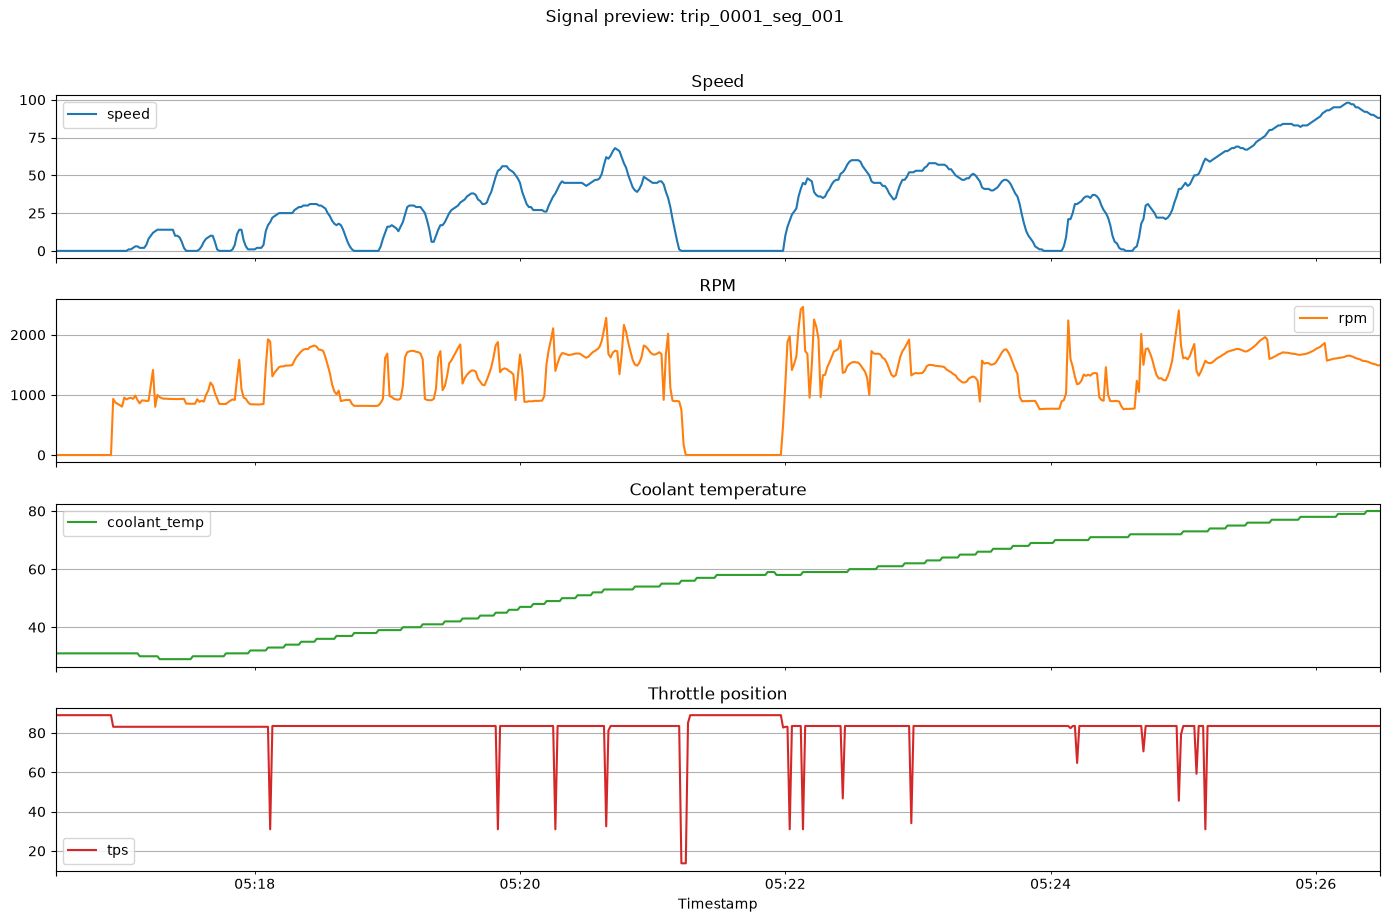

In [5]:
import matplotlib.pyplot as plt

try:
    preview_segment = cleaned["segment_id"].iloc[0]
    preview = cleaned.loc[cleaned["segment_id"].eq(preview_segment)].head(600).copy()
    preview = preview.set_index("timestamp")

    signal_columns = ["speed", "rpm", "coolant_temp", "tps"]
    axes = preview[signal_columns].plot(
        subplots=True,
        figsize=(14, 9),
        title=["Speed", "RPM", "Coolant temperature", "Throttle position"],
        grid=True,
    )
    for axis in axes:
        axis.set_xlabel("Timestamp")
    plt.suptitle(f"Signal preview: {preview_segment}", y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Visual preview skipped: {exc}")

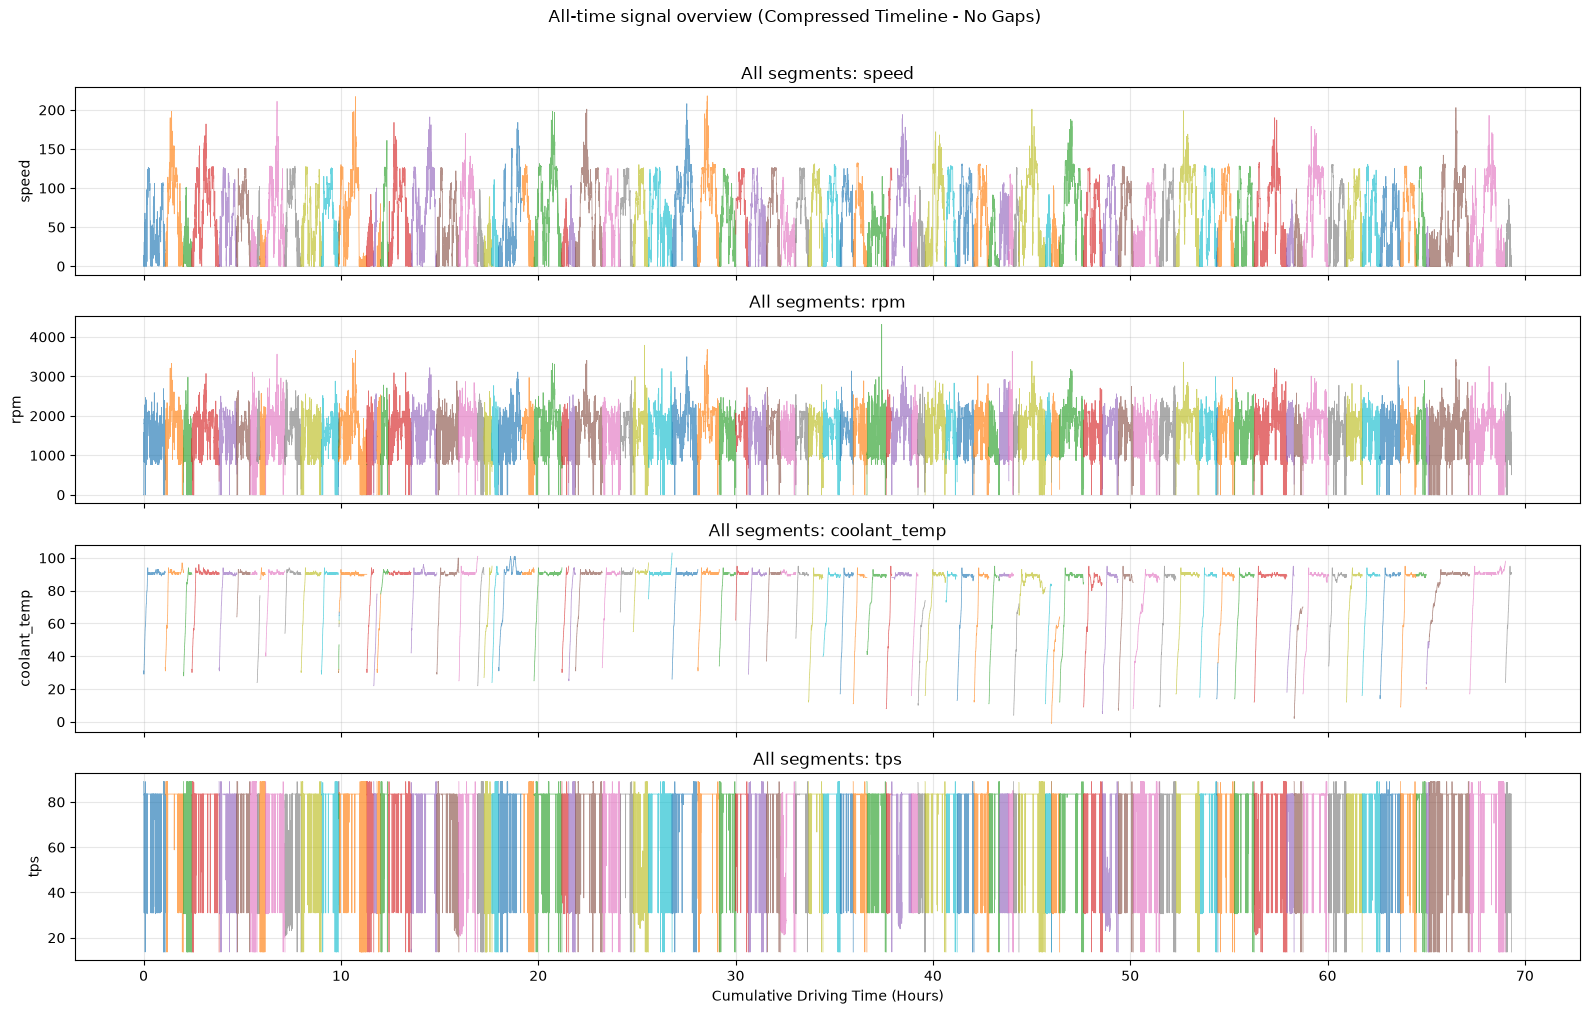

In [6]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "cleaned" not in globals():
        cleaned = pd.read_csv(CLEANED_DATASET)

    overview = cleaned.copy()
    overview["timestamp"] = pd.to_datetime(overview["timestamp"], utc=True)
    signal_columns = ["speed", "rpm", "coolant_temp", "tps"]

    overview["segment_secs"] = overview.groupby(["trip_id", "segment_id"], sort=False)["timestamp"].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    
    segment_durations = overview.groupby(
        ["trip_id", "segment_id"], sort=False
    )["segment_secs"].max()
    segment_offsets = segment_durations.cumsum().shift(1, fill_value=0)
    segment_keys = pd.MultiIndex.from_frame(overview[["trip_id", "segment_id"]])
    overview["continuous_secs"] = (
        overview["segment_secs"]
        + segment_offsets.reindex(segment_keys).to_numpy()
    )
    
    fig, axes = plt.subplots(
        len(signal_columns),
        1,
        figsize=(16, 10),
        sharex=True,
    )


    for axis, column in zip(axes, signal_columns):
        for _, segment in overview.groupby(["trip_id", "segment_id"], sort=False):
            axis.plot(
                segment["continuous_secs"] / 3600, 
                segment[column],
                linewidth=0.55,
                alpha=0.65,
            )
        axis.set_title(f"All segments: {column}")
        axis.set_ylabel(column)
        axis.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Cumulative Driving Time (Hours)")
    plt.suptitle("All-time signal overview (Compressed Timeline - No Gaps)", y=1.01)
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; all-time overview skipped.")
except Exception as exc:
    print(f"Error occurred: {exc}")

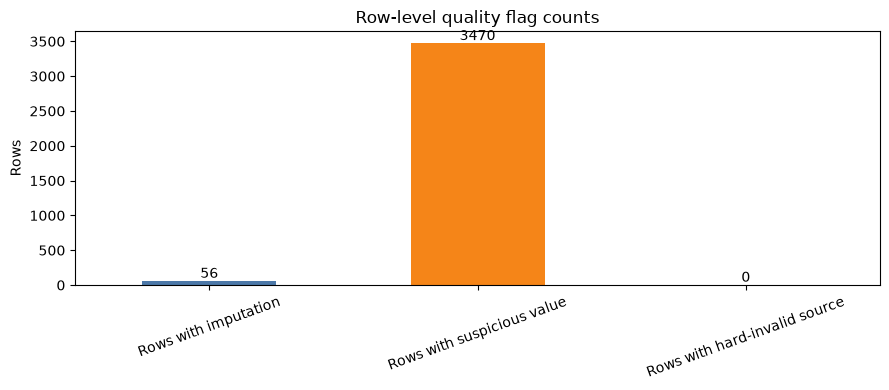

In [7]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "quality" not in globals():
        quality = pd.read_csv(QUALITY_CSV, low_memory=False)

    quality_counts = pd.Series({
        "Rows with imputation": int(quality["is_imputed_any"].sum()),
        "Rows with suspicious value": int(quality["is_suspicious_any"].sum()),
        "Rows with hard-invalid source": int(
            quality["had_hard_invalid_source_any"].sum()
        ),
    })

    ax = quality_counts.plot(kind="bar", figsize=(9, 4), color=["#4C78A8", "#F58518", "#E45756"])
    ax.set_title("Row-level quality flag counts")
    ax.set_ylabel("Rows")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.bar_label(ax.containers[0], fmt="%.0f")
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; quality chart skipped.")
except FileNotFoundError as exc:
    print(f"Required CSV file is missing: {exc.filename}. Run the cleaning and audit cells first.")

## Takeaways

- The selected reference run contains 249,694 canonical 1 Hz rows across 81 trips and 118 trip/segment pairs.
- The cleaned and quality tables satisfy the current ordered column contracts and share a unique four-column sample identity.
- All within-segment timestamp deltas are exactly one second in the reference artifact.
- The cleaning report records 56 rows with imputation, 3,470 rows with a suspicious value, and zero rows with a hard-invalid source.
- These findings support use of this reference run for downstream Data Layer processing; they do not establish real-fault detection performance or Model Layer accuracy.
